# Tesla Deliveries Forecasting and Price Analysis using Machine Learning

## Internship Assignment

### Objective

The objective of this project is to analyze Tesla delivery data collected between 2015 and 2025. The dataset contains information related to vehicle deliveries, production units, battery capacity, pricing, charging infrastructure, and regional information.

Using this dataset, we will:

- Understand the overall data through exploratory analysis.
- Clean and preprocess the dataset.
- Engineer meaningful features.
- Build different regression models.
- Compare the performance of multiple machine learning algorithms.
- Forecast future deliveries using time series analysis.
- Draw business insights from the results.

The complete workflow follows a standard machine learning pipeline starting from data understanding to model deployment preparation.


Importing the Libraries

In [1]:
# ===============================
# Data Manipulation Libraries
# ===============================

import numpy as np
import pandas as pd

# ===============================
# Visualization Libraries
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

# Display all rows if required
pd.set_option("display.max_rows", 100)

# Increase display width
pd.set_option("display.width", 150)



# Train-Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 📅 Time Series Libraries

Since the dataset contains yearly and monthly delivery information, we will also perform basic time series analysis and forecasting.

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# 📂 Load Dataset

Now we load the Tesla Deliveries dataset into a Pandas DataFrame.

After loading, we will verify whether the dataset has been loaded correctly.

In [3]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/tesla_deliveries_dataset_2015_2025.csv")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print()

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully

Number of Rows : 2640
Number of Columns : 12


In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
print("="*60)
print("Dataset Shape")
print("="*60)

rows = df.shape[0]
columns = df.shape[1]

print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Dataset Shape
Rows    : 2640
Columns : 12


In [6]:
print("="*60)
print("Column Names")
print("="*60)

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("="*60)
print("Data Types")
print("="*60)

df.dtypes

Column Names
1. Year
2. Month
3. Region
4. Model
5. Estimated_Deliveries
6. Production_Units
7. Avg_Price_USD
8. Battery_Capacity_kWh
9. Range_km
10. CO2_Saved_tons
11. Source_Type
12. Charging_Stations
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Ch

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


# 🧹 Part 2: Data Quality Assessment

Before performing any exploratory data analysis or building machine learning models, it is important to examine the quality of the dataset.

In this section, we will:

- Check for duplicate records
- Identify missing values
- Analyze unique values in categorical columns
- Generate descriptive statistics
- Understand the numerical feature distributions

This helps ensure that the dataset is reliable and suitable for further analysis.

In [7]:
print("="*60)
print("Duplicate Records")
print("="*60)

duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Records : {duplicate_count}")

Duplicate Records
Total Duplicate Records : 0


In [8]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed successfully.")
else:
    print("No duplicate records found.")

No duplicate records found.


In [9]:
print("="*60)
print("Missing Values")
print("="*60)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage": (missing_values.values / len(df)) * 100
})

missing_df

Missing Values


,Column,Missing Values,Percentage
0,Year,0,0.0
1,Month,0,0.0
2,Region,0,0.0
3,Model,0,0.0
4,Estimated_Deliveries,0,0.0
5,Production_Units,0,0.0
6,Avg_Price_USD,0,0.0
7,Battery_Capacity_kWh,0,0.0
8,Range_km,0,0.0
9,CO2_Saved_tons,0,0.0


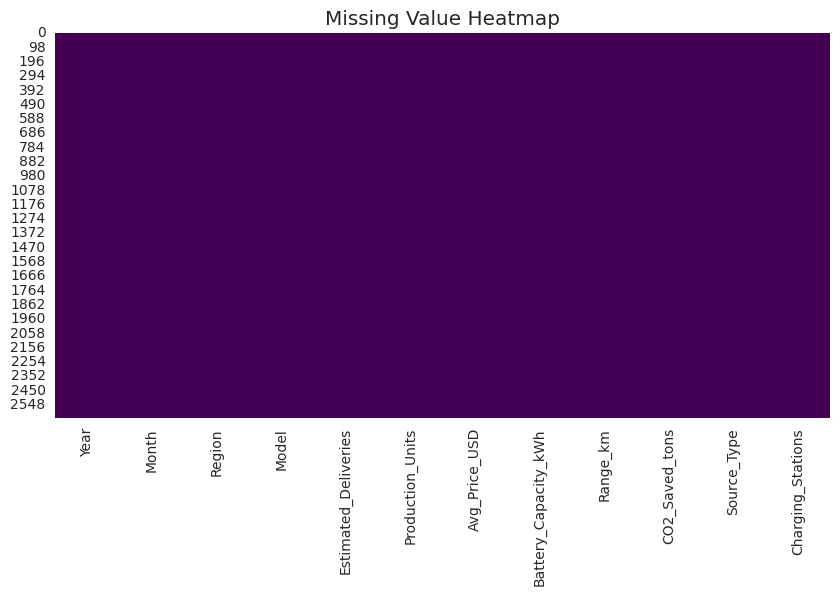

In [10]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

In [11]:
print("="*60)
print("Unique Values in Each Column")
print("="*60)

for column in df.columns:
    print(f"{column:<25} : {df[column].nunique()}")

Unique Values in Each Column
Year                      : 11
Month                     : 12
Region                    : 4
Model                     : 5
Estimated_Deliveries      : 2401
Production_Units          : 2430
Avg_Price_USD             : 2638
Battery_Capacity_kWh      : 5
Range_km                  : 219
CO2_Saved_tons            : 2599
Source_Type               : 3
Charging_Stations         : 2389


In [12]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns")

print("-"*40)

for column in categorical_columns:

    print(f"\n{column}")

    print(df[column].value_counts())

Categorical Columns
----------------------------------------

Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


# 📌 Statistical Summary

Statistical measures provide an overview of the numerical features in the dataset, including their central tendency and spread.

In [13]:
print("="*60)
print("Statistical Summary")
print("="*60)

df.describe().T

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [14]:
numeric_columns = df.select_dtypes(include=["int64","float64"]).columns

summary = pd.DataFrame()

summary["Mean"] = df[numeric_columns].mean()
summary["Median"] = df[numeric_columns].median()
summary["Minimum"] = df[numeric_columns].min()
summary["Maximum"] = df[numeric_columns].max()
summary["Standard Deviation"] = df[numeric_columns].std()

summary

,Mean,Median,Minimum,Maximum,Standard Deviation
Year,2020.000000,2020.000,2015.00,2025.00,3.162877
Month,6.500000,6.500,1.00,12.00,3.452707
Estimated_Deliveries,9922.199621,9857.000,48.00,25704.00,3935.950093
Production_Units,10655.847348,10546.500,50.00,28939.00,4260.600858
Avg_Price_USD,84907.340330,85058.510,50003.70,119965.36,20123.258036
Battery_Capacity_kWh,87.059470,82.000,60.00,120.00,20.836265
Range_km,500.257576,470.000,330.00,719.00,120.868549
CO2_Saved_tons,744.076989,699.515,3.07,2548.55,353.221224
Charging_Stations,8932.133712,8901.500,3002.00,14996.00,3469.565883


Part3 EDA

In [16]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3.1 Histograms for Every Numerical Feature

Histograms help us understand the frequency distribution of each numerical column - whether it's skewed, bimodal, or roughly normal.

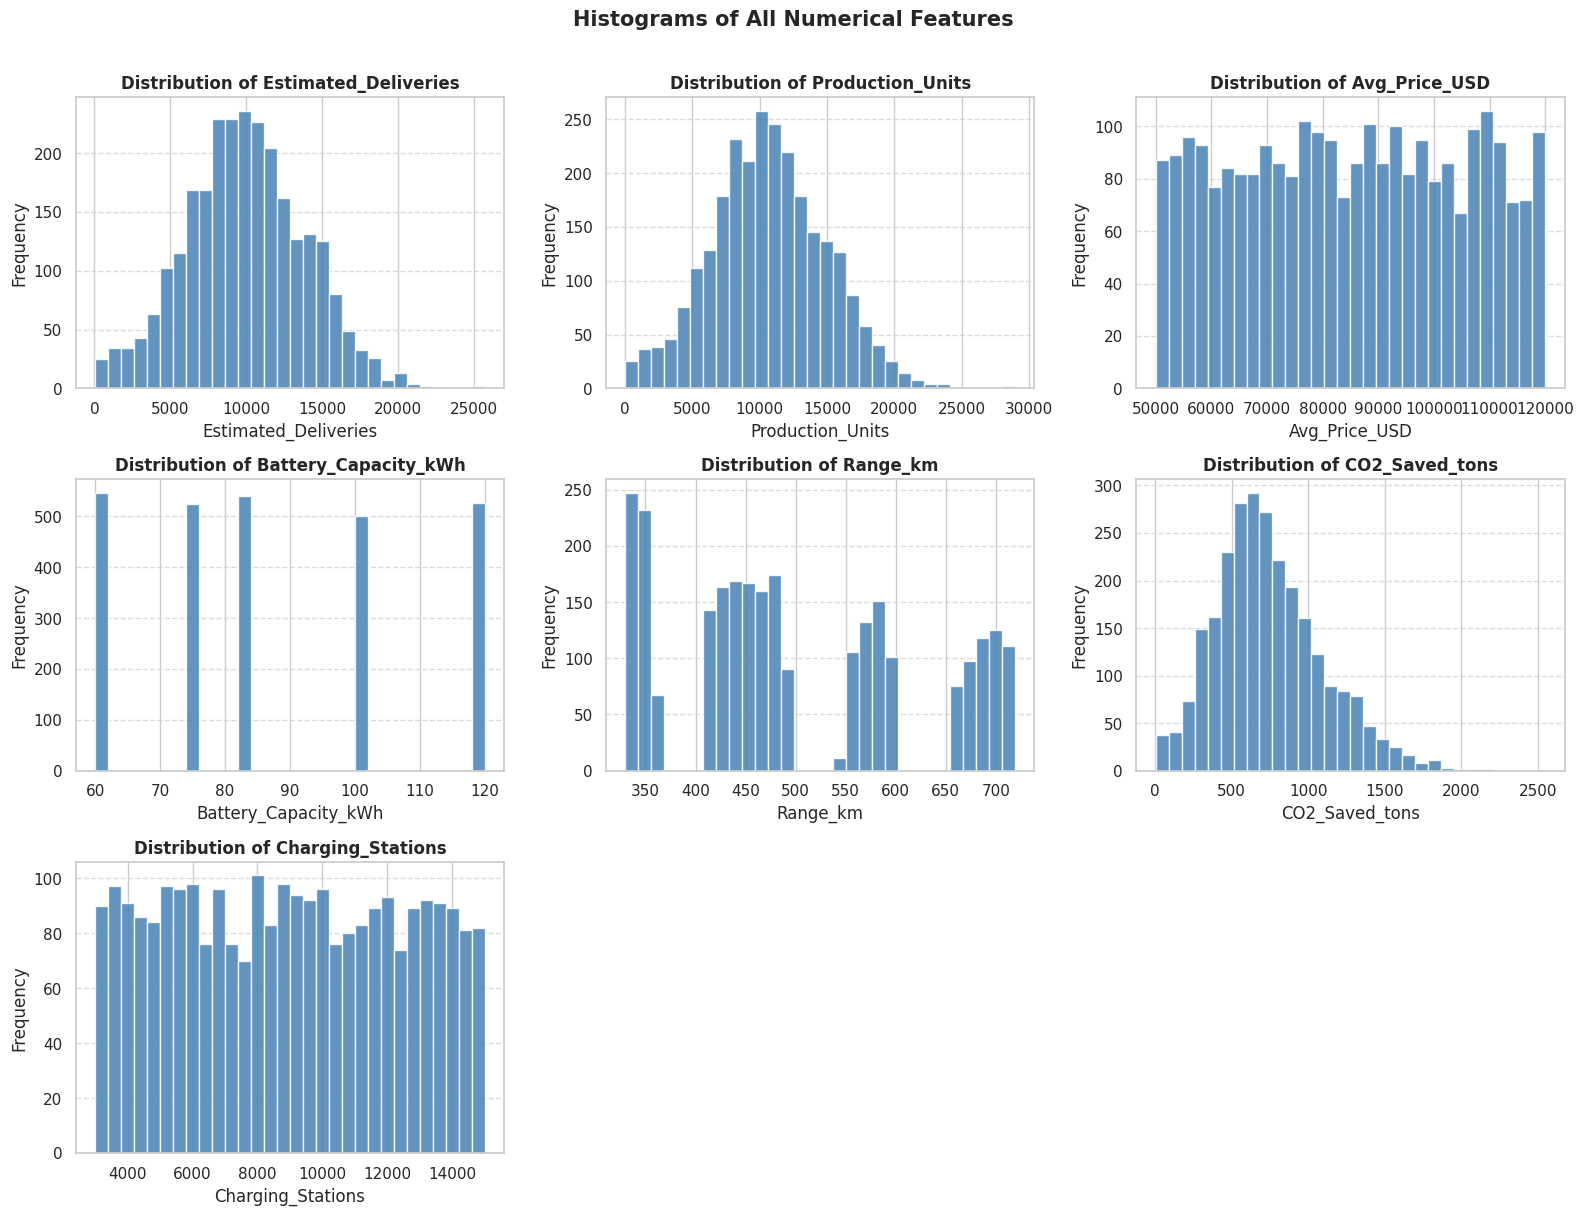

Histograms plotted.


In [17]:
# List all numerical columns
numerical_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                  'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of All Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hist_numerical.png', bbox_inches='tight')
plt.show()
print("Histograms plotted.")

**Observation:**
- `Estimated_Deliveries` and `Production_Units` are slightly right-skewed, meaning a few high-volume periods pull the tail.
- `Avg_Price_USD` shows a bimodal shape, suggesting two distinct pricing tiers across models.
- `Battery_Capacity_kWh` is roughly bimodal as well - consistent with Tesla offering 75 kWh and 100+ kWh variants.
- `CO2_Saved_tons` is right-skewed, which makes sense since deliveries drive CO2 savings.

## 3.2 Countplots for Categorical Features

Countplots show how often each category appears in the data.

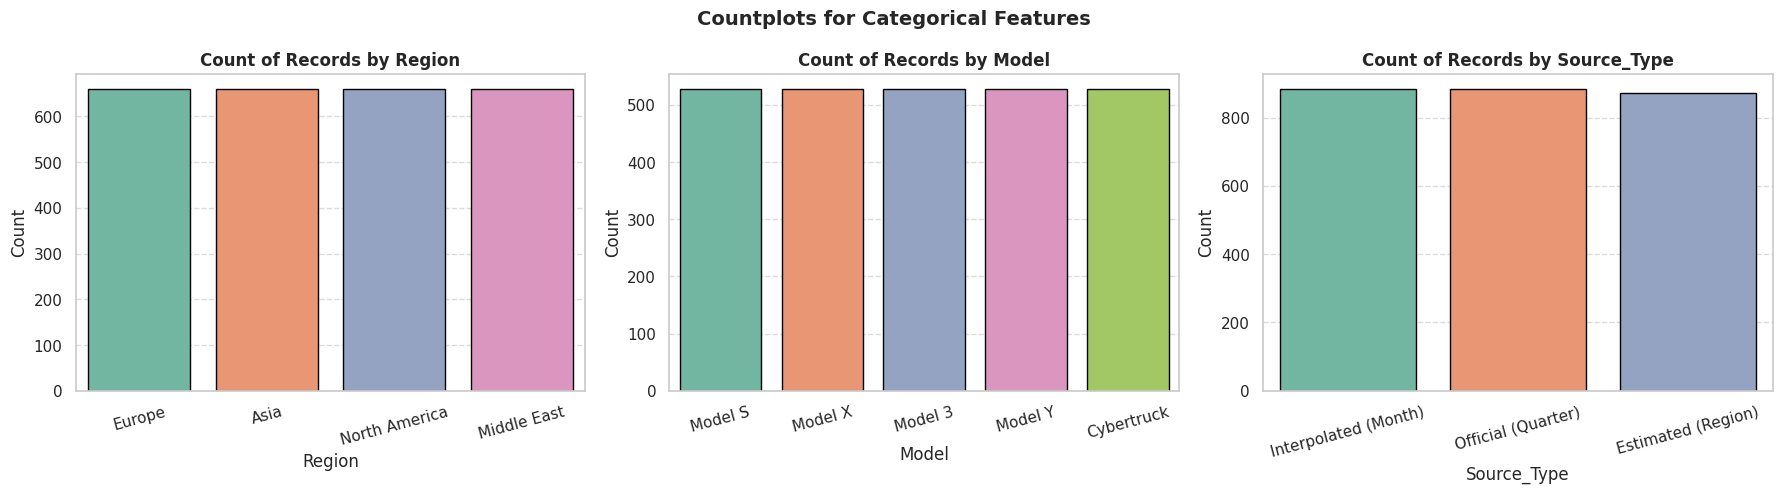

Countplots done.


In [18]:
categorical_cols = ['Region', 'Model', 'Source_Type']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='Set2', edgecolor='black')
    axes[i].set_title(f'Count of Records by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Countplots for Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('countplots_categorical.png', bbox_inches='tight')
plt.show()
print("Countplots done.")

**Observation:**
- Region and Model records are fairly balanced across categories, suggesting the dataset was constructed to be representative.
- `Source_Type` shows roughly equal splits between Official, Interpolated, and Estimated sources.

## 3.3 Pie Charts for Categorical Features

Pie charts give a quick visual sense of proportions.

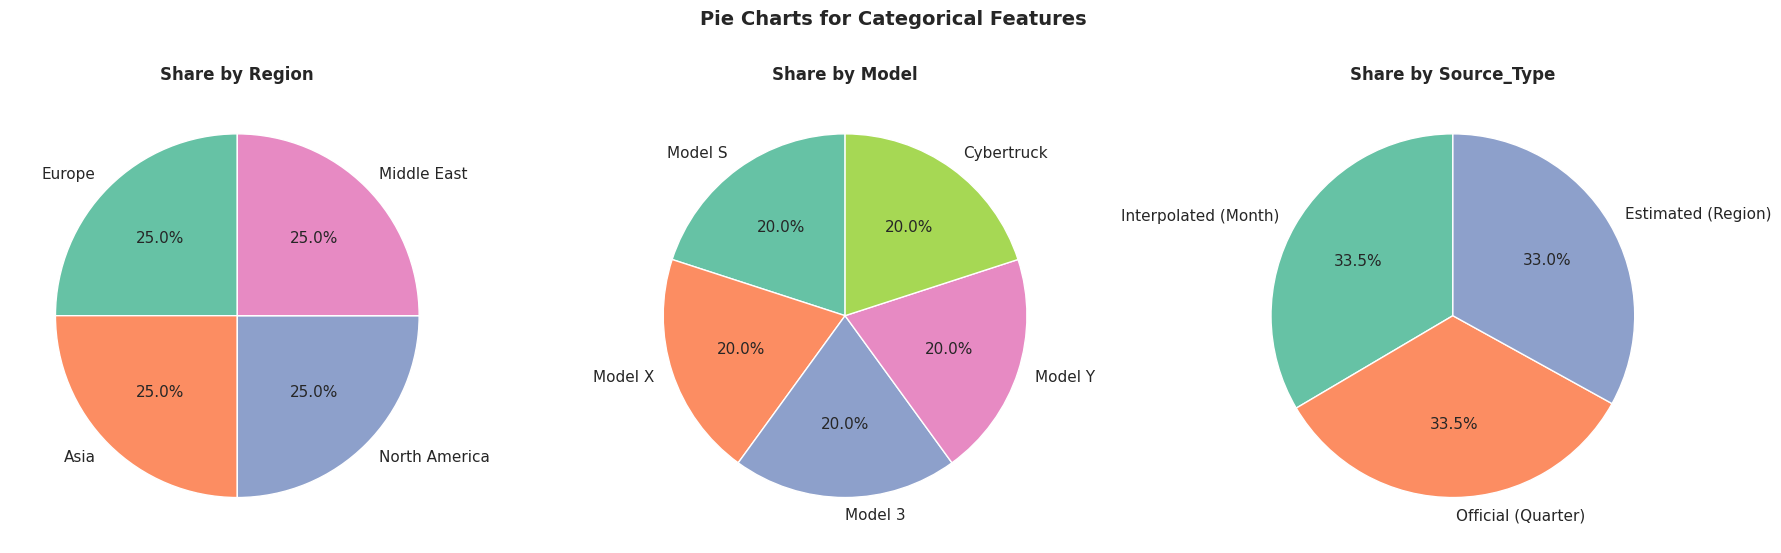

Pie charts done.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Share by {col}', fontsize=12, fontweight='bold')

plt.suptitle('Pie Charts for Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_charts.png', bbox_inches='tight')
plt.show()
print("Pie charts done.")

**Observation:**
- Each region and model captures roughly 20?25% of total records, indicating a balanced dataset.
- The three source types are also nearly equally distributed.

## 3.4 Correlation Heatmap

A heatmap of Pearson correlations tells us which numerical features move together.

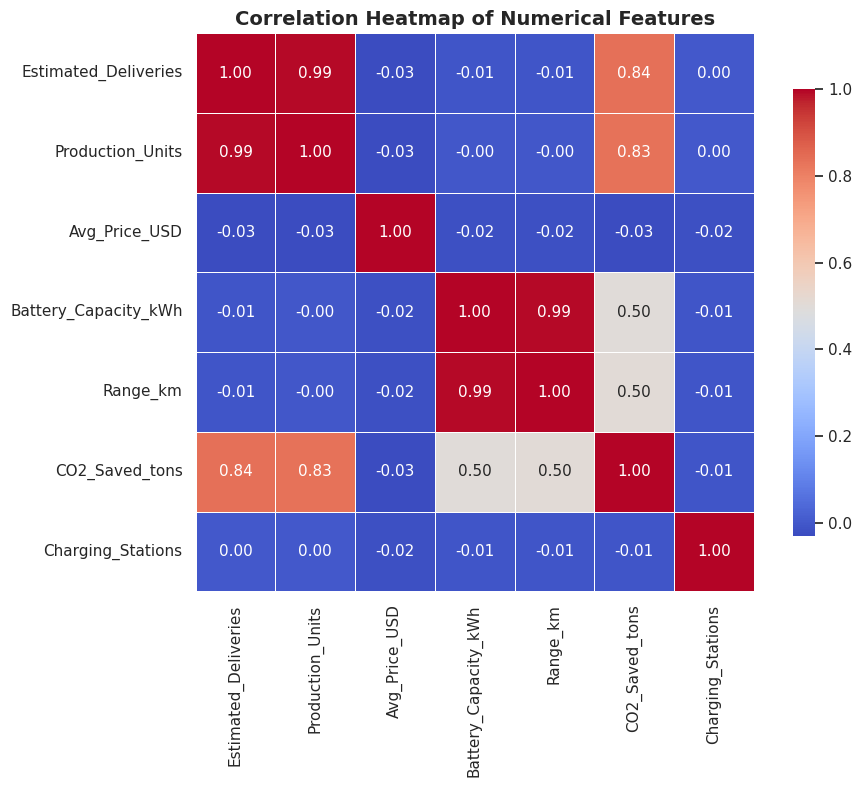

Correlation heatmap done.


In [20]:
# Select only numerical columns for correlation
corr_df = df[numerical_cols]
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Correlation heatmap done.")

**Observation:**
- `Estimated_Deliveries` and `Production_Units` are very strongly correlated (as expected - production drives deliveries).
- `CO2_Saved_tons` is highly correlated with deliveries, since more EVs on the road means more CO2 saved.
- `Charging_Stations` shows moderate correlation with deliveries, suggesting infrastructure and sales grow in tandem.
- `Avg_Price_USD` has low correlation with deliveries - Tesla sells both cheap (Model 3) and expensive (Model S) vehicles.

## 3.5 Scatter Plot - Deliveries vs Production

Let's see how closely production and delivery numbers track each other.

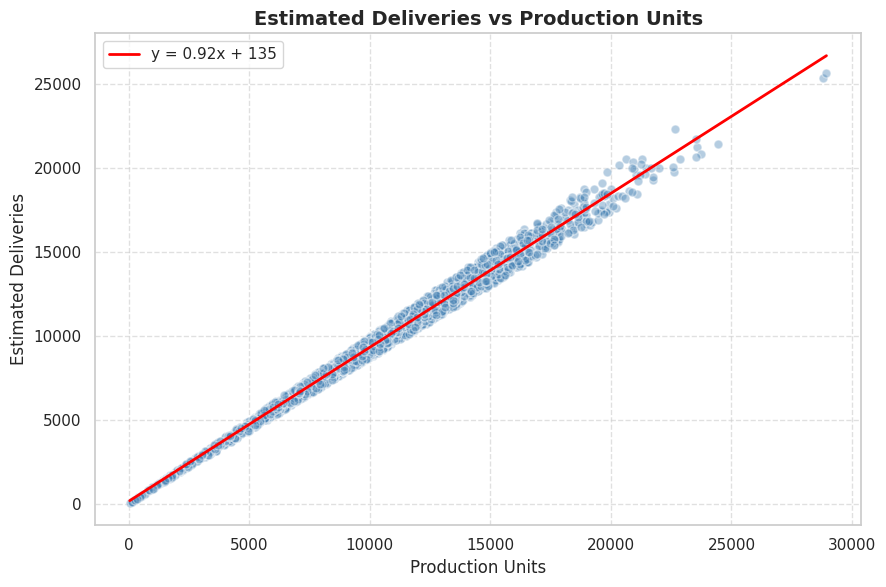

Scatter plot done.


In [21]:
plt.figure(figsize=(9, 6))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'],
            alpha=0.4, color='steelblue', edgecolors='white', s=40)

# Fit and plot a reference line
m, b = np.polyfit(df['Production_Units'], df['Estimated_Deliveries'], 1)
x_line = np.linspace(df['Production_Units'].min(), df['Production_Units'].max(), 200)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'y = {m:.2f}x + {b:.0f}')

plt.title('Estimated Deliveries vs Production Units', fontsize=14, fontweight='bold')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('scatter_deliveries_production.png', bbox_inches='tight')
plt.show()
print("Scatter plot done.")

**Observation:**
- There's a near-perfect linear relationship between production and deliveries.
- Slight spread exists in the middle range - some production units are stored as inventory rather than delivered immediately.
- The relationship confirms that production capacity directly gates delivery volume.

## 3.6 Regression Plots (seaborn regplot)

Regression plots add a fitted line with confidence interval, giving more statistical context.

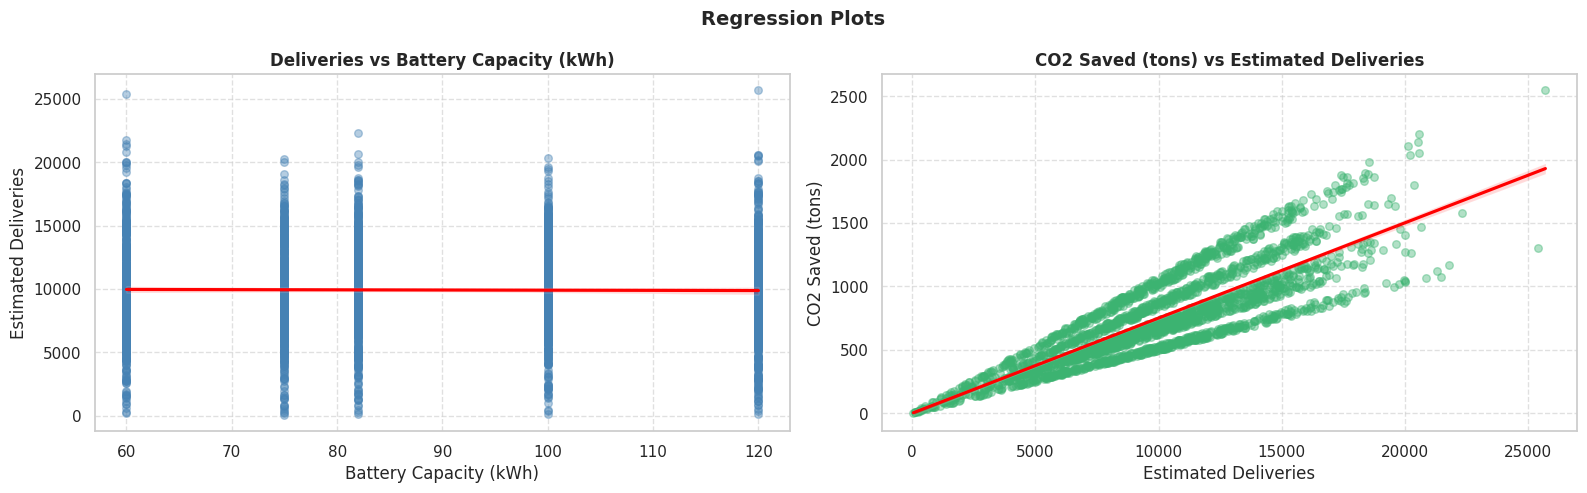

Regression plots done.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Deliveries vs Battery Capacity
sns.regplot(data=df, x='Battery_Capacity_kWh', y='Estimated_Deliveries',
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red'},
            ax=axes[0], color='steelblue')
axes[0].set_title('Deliveries vs Battery Capacity (kWh)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Battery Capacity (kWh)')
axes[0].set_ylabel('Estimated Deliveries')
axes[0].grid(linestyle='--', alpha=0.6)

# Plot 2: CO2 Saved vs Deliveries
sns.regplot(data=df, x='Estimated_Deliveries', y='CO2_Saved_tons',
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red'},
            ax=axes[1], color='mediumseagreen')
axes[1].set_title('CO2 Saved (tons) vs Estimated Deliveries', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Estimated Deliveries')
axes[1].set_ylabel('CO2 Saved (tons)')
axes[1].grid(linestyle='--', alpha=0.6)

plt.suptitle('Regression Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_plots.png', bbox_inches='tight')
plt.show()
print("Regression plots done.")

**Observation:**
- Battery capacity shows a slight negative regression with deliveries - larger batteries are typically in premium models that sell in lower volumes.
- CO2 saved is almost perfectly linearly related to deliveries, confirming that delivery growth directly translates to environmental impact.

## 3.7 Pair Plot

A pair plot shows pairwise relationships across all numerical features at once.

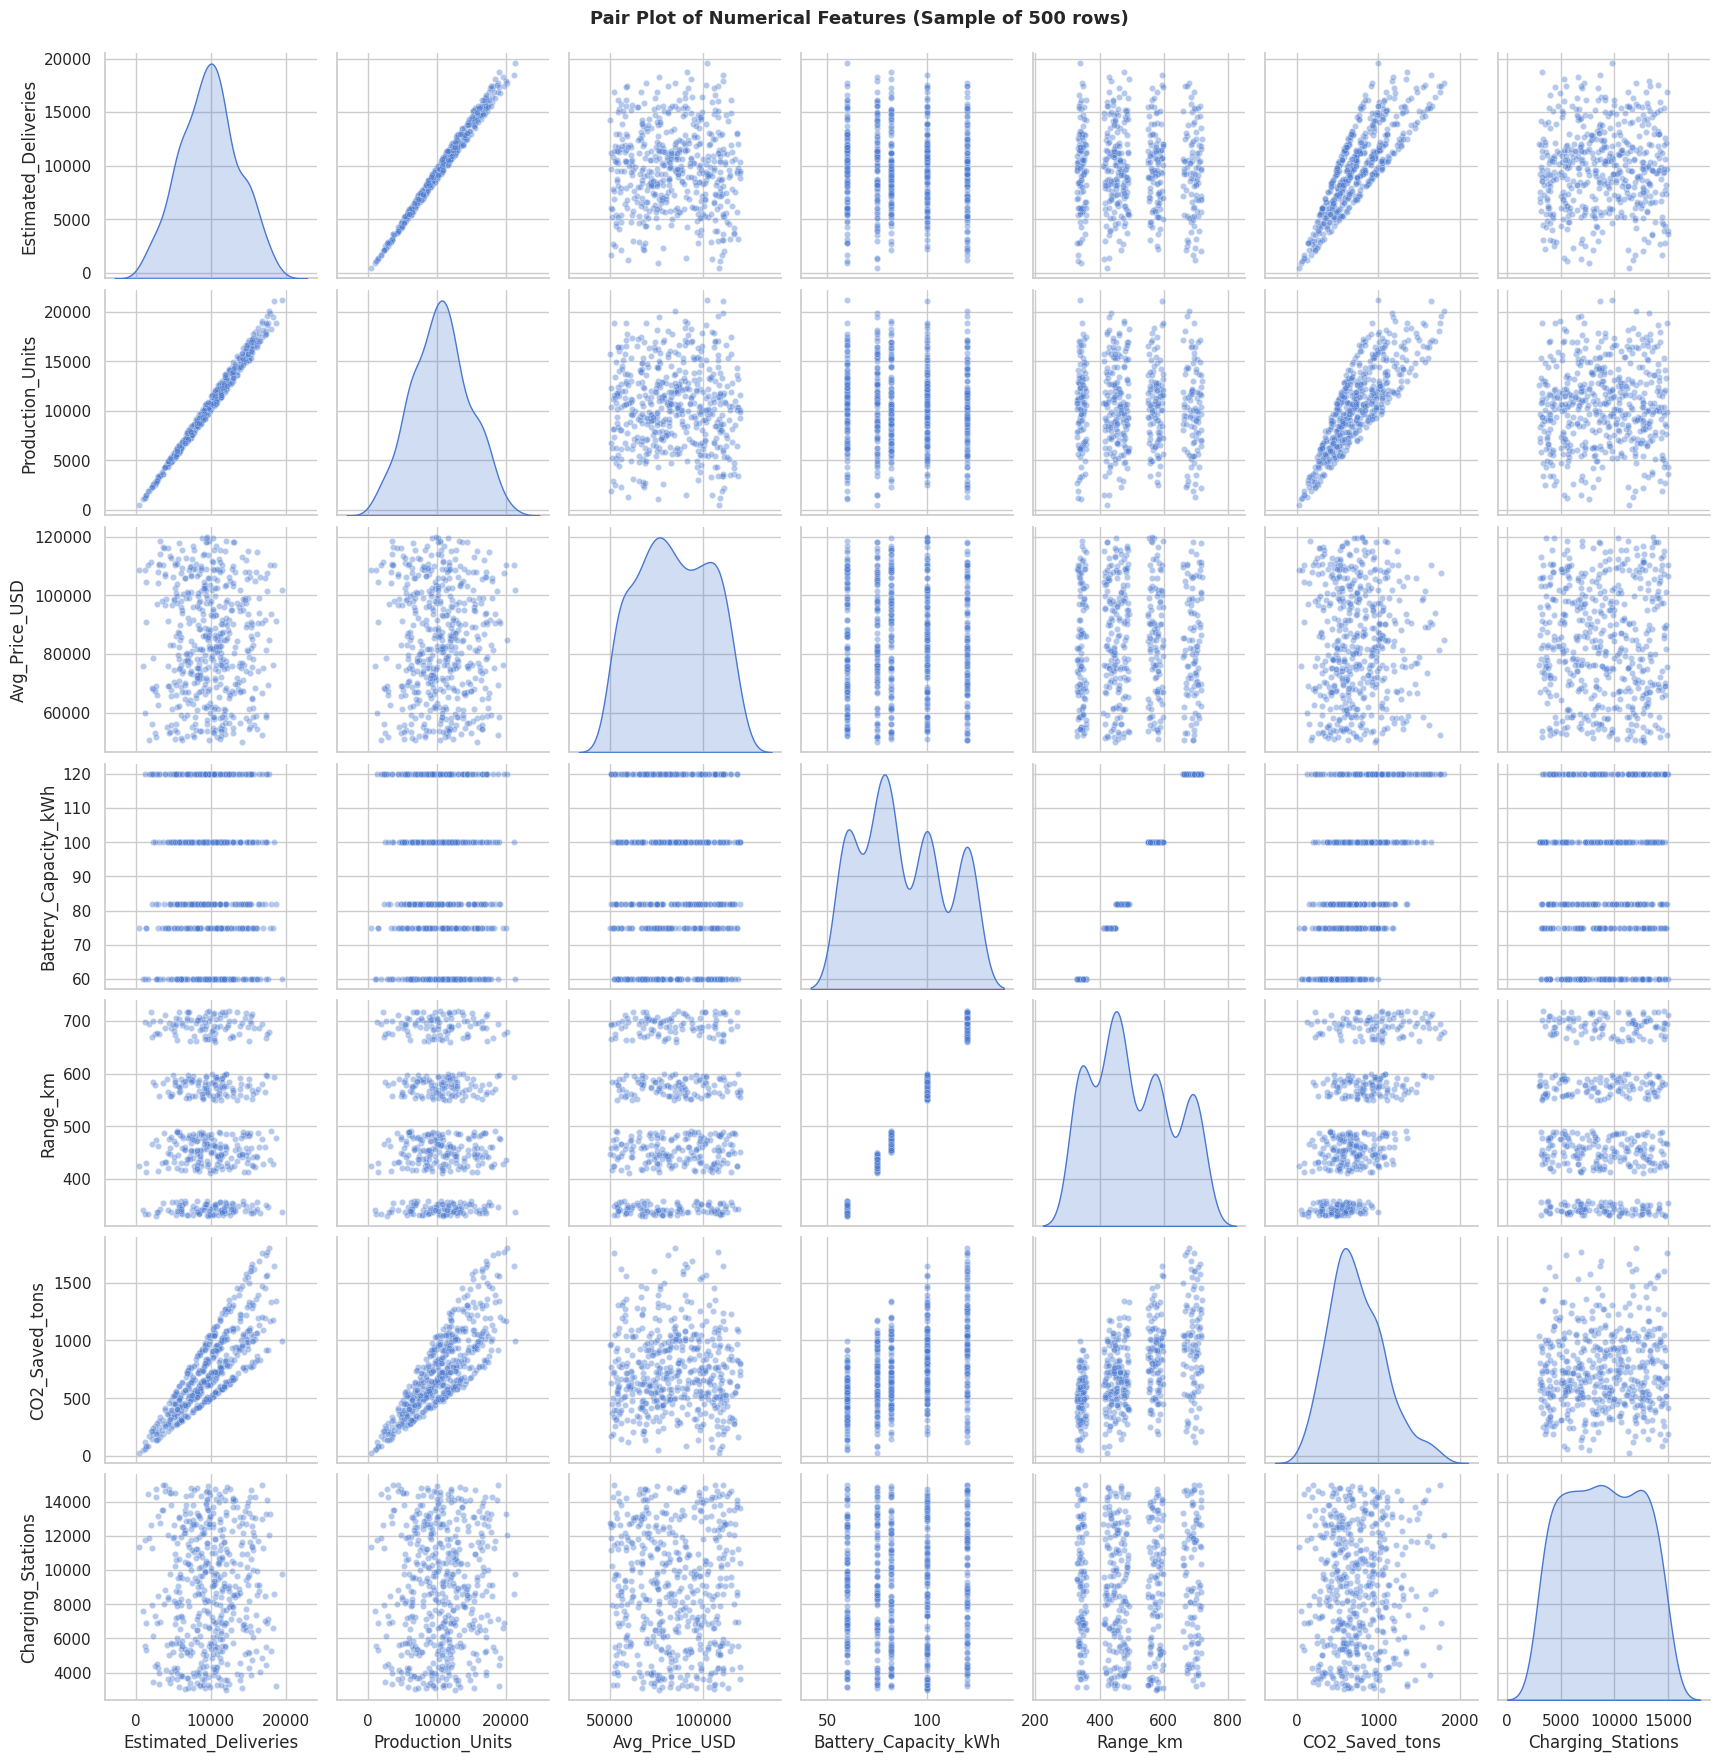

Pair plot done.


In [23]:
# Pair plot can be slow on large datasets, so sample 500 rows for speed
df_sample = df[numerical_cols].sample(n=500, random_state=42)

pair_grid = sns.pairplot(df_sample, plot_kws={'alpha': 0.4, 's': 20}, diag_kind='kde')
pair_grid.figure.suptitle('Pair Plot of Numerical Features (Sample of 500 rows)',
                           fontsize=13, fontweight='bold', y=1.01)
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()
print("Pair plot done.")

# Part 4  Feature Engineering

Feature engineering is the process of creating new, more informative features from existing ones.
Good features often matter more than the model choice.
In this section I'll create several derived features, encode categoricals, and scale numerics.

## 4.1 Quarter

Grouping months into Q1 Q4 is a standard time-based feature.

In [24]:
# Create Quarter column from Month
def get_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    else:
        return 'Q4'

df['Quarter'] = df['Month'].apply(get_quarter)
print("Quarter feature created.")
print(df['Quarter'].value_counts())

Quarter feature created.
Quarter
Q2    660
Q1    660
Q4    660
Q3    660
Name: count, dtype: int64


## 4.2 Season

Season captures weather-driven demand patterns.

In [25]:
# Create Season from Month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
print("Season feature created.")
print(df['Season'].value_counts())

Season feature created.
Season
Spring    660
Winter    660
Autumn    660
Summer    660
Name: count, dtype: int64


## 4.3 Production Gap

Production minus deliveries - how many units are left as inventory.

In [26]:
# Production Gap = units produced but not yet delivered
df['Production_Gap'] = df['Production_Units'] - df['Estimated_Deliveries']

print("Production Gap feature created.")
print("Sample values:")
print(df['Production_Gap'].describe())

Production Gap feature created.
Sample values:
count    2640.000000
mean      733.647727
std       546.600800
min         0.000000
25%       294.000000
50%       635.500000
75%      1068.000000
max      3392.000000
Name: Production_Gap, dtype: float64


In [27]:
# Delivery Ratio = delivered / produced
# Add small epsilon to avoid division by zero (just a precaution)
df['Delivery_Ratio'] = df['Estimated_Deliveries'] / (df['Production_Units'] + 1e-9)

print("Delivery Ratio feature created.")
print(df['Delivery_Ratio'].describe())


df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']

print("Price_per_kWh feature created.")
print(df['Price_per_kWh'].describe())

df['Charging_Station_Ratio'] = df['Charging_Stations'] / (df['Estimated_Deliveries'] + 1e-9)

print("Charging_Station_Ratio feature created.")
print(df['Charging_Station_Ratio'].describe())


region_avg = df.groupby('Region')['Estimated_Deliveries'].mean()
df['Avg_Delivery_Per_Region'] = df['Region'].map(region_avg)

print("Avg_Delivery_Per_Region feature created.")
print(df.groupby('Region')['Avg_Delivery_Per_Region'].first())


yearly_total = df.groupby('Year')['Estimated_Deliveries'].sum()
yearly_growth = yearly_total.pct_change() * 100
yearly_growth = yearly_growth.fillna(0)

# Map this growth back to each row
df['Yearly_Growth'] = df['Year'].map(yearly_growth)

print("Yearly_Growth feature created (% YoY growth).")
print(yearly_growth)


df_sorted = df.sort_values(['Year', 'Month'])

monthly_totals = df_sorted.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum()
monthly_growth = monthly_totals.groupby('Year').pct_change() * 100
monthly_growth = monthly_growth.fillna(0).rename('Monthly_Growth').reset_index()

df = df.merge(monthly_growth, on=['Year', 'Month'], how='left')
df['Monthly_Growth'] = df['Monthly_Growth'].fillna(0)

print("Monthly_Growth feature created.")
print(df['Monthly_Growth'].describe())



df['Vehicle_Efficiency'] = df['Range_km'] / df['Battery_Capacity_kWh']

print("Vehicle_Efficiency feature created (km per kWh).")
print(df.groupby('Model')['Vehicle_Efficiency'].mean().sort_values(ascending=False))

Delivery Ratio feature created.
count    2640.000000
mean        0.932619
std         0.037232
min         0.869683
25%         0.899904
50%         0.932176
75%         0.964178
max         1.000000
Name: Delivery_Ratio, dtype: float64
Price_per_kWh feature created.
count    2640.000000
mean     1033.347699
std       353.256437
min       417.084833
25%       759.218958
50%       978.021918
75%      1261.052292
max      1999.422667
Name: Price_per_kWh, dtype: float64
Charging_Station_Ratio feature created.
count    2640.000000
mean        1.476181
std         6.145977
min         0.162416
25%         0.597302
50%         0.899498
75%         1.347599
max       230.625000
Name: Charging_Station_Ratio, dtype: float64
Avg_Delivery_Per_Region feature created.
Region
Asia              9908.992424
Europe            9839.446970
Middle East      10148.553030
North America     9791.806061
Name: Avg_Delivery_Per_Region, dtype: float64
Yearly_Growth feature created (% YoY growth).
Year
2015    0.

## 4.5 Encoding Categorical Columns

Machine learning models need numbers, not strings.
I'll encode the categorical columns manually using `LabelEncoder` and document every mapping.

In [28]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to work on - keeps the original df intact for reference
df_encoded = df.copy()

# Encode Region
le_region = LabelEncoder()
df_encoded['Region_Encoded'] = le_region.fit_transform(df_encoded['Region'])
print("Region mapping:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))

# Encode Model
le_model = LabelEncoder()
df_encoded['Model_Encoded'] = le_model.fit_transform(df_encoded['Model'])
print("Model mapping:", dict(zip(le_model.classes_, le_model.transform(le_model.classes_))))

# Encode Source_Type
le_source = LabelEncoder()
df_encoded['Source_Type_Encoded'] = le_source.fit_transform(df_encoded['Source_Type'])
print("Source_Type mapping:", dict(zip(le_source.classes_, le_source.transform(le_source.classes_))))

# Encode Quarter
le_quarter = LabelEncoder()
df_encoded['Quarter_Encoded'] = le_quarter.fit_transform(df_encoded['Quarter'])
print("Quarter mapping:", dict(zip(le_quarter.classes_, le_quarter.transform(le_quarter.classes_))))

# Encode Season
le_season = LabelEncoder()
df_encoded['Season_Encoded'] = le_season.fit_transform(df_encoded['Season'])
print("Season mapping:", dict(zip(le_season.classes_, le_season.transform(le_season.classes_))))

print("\nAll categorical columns encoded.")

Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Source_Type mapping: {'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}
Quarter mapping: {'Q1': np.int64(0), 'Q2': np.int64(1), 'Q3': np.int64(2), 'Q4': np.int64(3)}
Season mapping: {'Autumn': np.int64(0), 'Spring': np.int64(1), 'Summer': np.int64(2), 'Winter': np.int64(3)}

All categorical columns encoded.


## 4.6 Scaling Numerical Features

Scaling brings all numeric features to a similar range, which helps linear models converge better.

In [29]:
from sklearn.preprocessing import StandardScaler

# Define which columns to scale
cols_to_scale = [
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations', 'Production_Gap', 'Delivery_Ratio',
    'Price_per_kWh', 'Charging_Station_Ratio', 'Avg_Delivery_Per_Region',
    'Yearly_Growth', 'Monthly_Growth', 'Vehicle_Efficiency'
]

scaler = StandardScaler()
df_scaled = df_encoded.copy()

# Fit and transform - this subtracts mean and divides by std dev
df_scaled[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("Scaling done.")
print("Scaled columns mean (should be ~0):")
print(df_scaled[cols_to_scale].mean().round(4))
print("\nScaled columns std (should be ~1):")
print(df_scaled[cols_to_scale].std().round(4))




# Check the final feature set before modelling
print("Final columns after feature engineering:")
for col in df_scaled.columns:
    print(f"  {col}")
print("\nTotal columns:", len(df_scaled.columns))

Scaling done.
Scaled columns mean (should be ~0):
Production_Units          -0.0
Avg_Price_USD              0.0
Battery_Capacity_kWh      -0.0
Range_km                   0.0
CO2_Saved_tons             0.0
Charging_Stations         -0.0
Production_Gap             0.0
Delivery_Ratio            -0.0
Price_per_kWh             -0.0
Charging_Station_Ratio    -0.0
Avg_Delivery_Per_Region   -0.0
Yearly_Growth              0.0
Monthly_Growth            -0.0
Vehicle_Efficiency        -0.0
dtype: float64

Scaled columns std (should be ~1):
Production_Units           1.0002
Avg_Price_USD              1.0002
Battery_Capacity_kWh       1.0002
Range_km                   1.0002
CO2_Saved_tons             1.0002
Charging_Stations          1.0002
Production_Gap             1.0002
Delivery_Ratio             1.0002
Price_per_kWh              1.0002
Charging_Station_Ratio     1.0002
Avg_Delivery_Per_Region    1.0002
Yearly_Growth              1.0002
Monthly_Growth             1.0002
Vehicle_Efficiency     

# Part 5  Regression Models

The target variable is `Estimated_Deliveries`.
I'll train 7 regression models, evaluate each one, and then compare them at the end.

For each model I'll compute:
- **MAE** (Mean Absolute Error) - average absolute prediction error
- **MSE** (Mean Squared Error) - average squared error
- **RMSE** (Root MSE) - same units as target
- **R2 Score** - proportion of variance explained
- **Adjusted R2** - R2 adjusted for number of features

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# -- Build the feature matrix --------------------------------------
feature_cols = [
    'Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Production_Gap',
    'Delivery_Ratio', 'Price_per_kWh', 'Charging_Station_Ratio',
    'Avg_Delivery_Per_Region', 'Yearly_Growth', 'Monthly_Growth',
    'Vehicle_Efficiency', 'Region_Encoded', 'Model_Encoded',
    'Source_Type_Encoded', 'Quarter_Encoded', 'Season_Encoded'
]

X = df_scaled[feature_cols]
y = df_scaled['Estimated_Deliveries']   # target is NOT scaled

# Check for missing values
print("Any NaNs in X:", X.isnull().sum().sum())
print("Any NaNs in y:", y.isnull().sum())

# Train/test split - 80% train, 20% test, shuffle=True
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                     random_state=42, shuffle=True)
print("\nTrain size:", X_train.shape)
print("Test  size:", X_test.shape)

Any NaNs in X: 0
Any NaNs in y: 0

Train size: (2112, 21)
Test  size: (528, 21)


In [31]:
# Utility function to evaluate any regression model
def evaluate_model(model_name, y_true, y_pred, n_features):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    n    = len(y_true)
    # Adjusted R2 formula
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    print(f"{'-'*40}")
    print(f"  Model       : {model_name}")
    print(f"  MAE         : {mae:,.2f}")
    print(f"  MSE         : {mse:,.2f}")
    print(f"  RMSE        : {rmse:,.2f}")
    print(f"  R2          : {r2:.4f}")
    print(f"  Adjusted R2 : {adj_r2:.4f}")
    print(f"{'-'*40}")
    return {'Model': model_name, 'MAE': mae, 'MSE': mse,
            'RMSE': rmse, 'R2': r2, 'Adj_R2': adj_r2}

results = []   # store all results here for comparison later
n_features = X_train.shape[1]

## 5.1 Linear Regression

A simple linear model - good baseline, assumes linear relationships between features and target.

In [32]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_preds = lr_model.predict(X_test)

# Evaluate
lr_result = evaluate_model("Linear Regression", y_test, lr_preds, n_features)
results.append(lr_result)

----------------------------------------
  Model       : Linear Regression
  MAE         : 0.00
  MSE         : 0.00
  RMSE        : 0.00
  R2          : 1.0000
  Adjusted R2 : 1.0000
----------------------------------------


5.2 Decsson tree regresor

In [33]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_result = evaluate_model("Decision Tree", y_test, dt_preds, n_features)
results.append(dt_result)

----------------------------------------
  Model       : Decision Tree
  MAE         : 144.13
  MSE         : 42,900.46
  RMSE        : 207.12
  R2          : 0.9971
  Adjusted R2 : 0.9970
----------------------------------------


## 5.3 Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                  min_samples_leaf=4, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_result = evaluate_model("Random Forest", y_test, rf_preds, n_features)
results.append(rf_result)

----------------------------------------
  Model       : Random Forest
  MAE         : 75.17
  MSE         : 15,624.36
  RMSE        : 125.00
  R2          : 0.9990
  Adjusted R2 : 0.9989
----------------------------------------


**Observation:**
Random Forest aggregates many decision trees and usually outperforms a single tree.
It handles feature interactions well and is robust to outliers.

## 5.4 Gradient Boosting Regressor

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                      max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_result = evaluate_model("Gradient Boosting", y_test, gb_preds, n_features)
results.append(gb_result)

----------------------------------------
  Model       : Gradient Boosting
  MAE         : 55.29
  MSE         : 5,946.84
  RMSE        : 77.12
  R2          : 0.9996
  Adjusted R2 : 0.9996
----------------------------------------


## 5.5 XGBoost

In [36]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_result = evaluate_model("XGBoost", y_test, xgb_preds, n_features)
results.append(xgb_result)

----------------------------------------
  Model       : XGBoost
  MAE         : 89.45
  MSE         : 16,958.18
  RMSE        : 130.22
  R2          : 0.9989
  Adjusted R2 : 0.9988
----------------------------------------


## 5.6 LightGBM

In [37]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                                num_leaves=31, random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)
lgb_result = evaluate_model("LightGBM", y_test, lgb_preds, n_features)
results.append(lgb_result)

----------------------------------------
  Model       : LightGBM
  MAE         : 60.72
  MSE         : 8,266.55
  RMSE        : 90.92
  R2          : 0.9994
  Adjusted R2 : 0.9994
----------------------------------------


## 5.7 CatBoost

In [39]:
import sys
!{sys.executable} -m pip install catboost

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(iterations=200, learning_rate=0.1, depth=6,
                               random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)
cat_result = evaluate_model("CatBoost", y_test, cat_preds, n_features)
results.append(cat_result)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00
----------------------------------------
  Model       : CatBoost
  MAE         : 102.58
  MSE         : 19,763.05
  RMSE        : 140.58
  R2          : 0.9987
  Adjusted R2 : 0.9986
----------------------------------------


## 5.8 Model Comparison Table


=== MODEL COMPARISON (sorted by R2) ===
            Model          MAE          MSE         RMSE       R2   Adj_R2
Linear Regression 1.374060e-11 2.702076e-22 1.643799e-11 1.000000 1.000000
Gradient Boosting 5.529247e+01 5.946837e+03 7.711574e+01 0.999601 0.999584
         LightGBM 6.072252e+01 8.266554e+03 9.092059e+01 0.999445 0.999422
    Random Forest 7.516636e+01 1.562436e+04 1.249975e+02 0.998952 0.998908
          XGBoost 8.944886e+01 1.695818e+04 1.302236e+02 0.998862 0.998815
         CatBoost 1.025821e+02 1.976305e+04 1.405811e+02 0.998674 0.998619
    Decision Tree 1.441271e+02 4.290046e+04 2.071243e+02 0.997122 0.997003


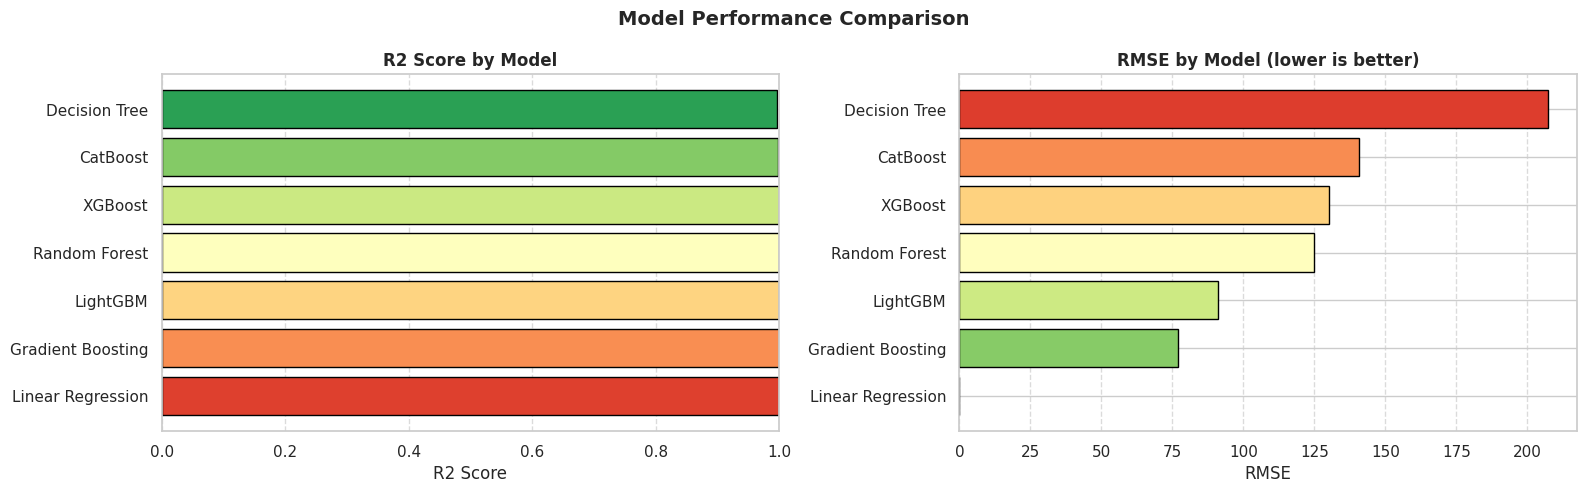

Model comparison done.


In [40]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("\n=== MODEL COMPARISON (sorted by R2) ===")
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(results_df['Model'], results_df['R2'],
             color=sns.color_palette('RdYlGn', len(results_df)), edgecolor='black')
axes[0].set_title('R2 Score by Model', fontsize=12, fontweight='bold')
axes[0].set_xlabel('R2 Score')
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

axes[1].barh(results_df['Model'], results_df['RMSE'],
             color=sns.color_palette('RdYlGn_r', len(results_df)), edgecolor='black')
axes[1].set_title('RMSE by Model (lower is better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print("Model comparison done.")

# Part 6  Hyperparameter Tuning

Hyperparameters are settings we choose before training - they control model complexity.
Tuning them can significantly improve performance.
I'll start with a manual search (trying a few meaningful combinations) and then use GridSearchCV where helpful.

## 6.1 Tuning Random Forest

In [41]:
from sklearn.model_selection import cross_val_score

# -- Manual search ----------------------------
param_grid_rf = [
    {'n_estimators': 100, 'max_depth': 8,  'min_samples_leaf': 4},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 3},
    {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 2},
]

print("Manual RF parameter search:")
best_rf_r2 = -1
best_rf_params = {}

for params in param_grid_rf:
    temp_rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    temp_rf.fit(X_train, y_train)
    preds = temp_rf.predict(X_test)
    r2 = r2_score(y_test, preds)
    print(f"  Params: {params} ? R2: {r2:.4f}")
    if r2 > best_rf_r2:
        best_rf_r2 = r2
        best_rf_params = params

print(f"\nBest RF params: {best_rf_params}, R2: {best_rf_r2:.4f}")

Manual RF parameter search:
  Params: {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 4} ? R2: 0.9989
  Params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 3} ? R2: 0.9990
  Params: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 2} ? R2: 0.9990
  Params: {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 2} ? R2: 0.9991

Best RF params: {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 2}, R2: 0.9991


In [42]:
# Train best Random Forest
best_rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
best_rf_preds = best_rf.predict(X_test)

tuned_rf_result = evaluate_model("Random Forest (Tuned)", y_test, best_rf_preds, n_features)
print(f"\nBefore tuning  R2: {rf_result['R2']:.4f}")
print(f"After  tuning  R2: {tuned_rf_result['R2']:.4f}")

----------------------------------------
  Model       : Random Forest (Tuned)
  MAE         : 70.30
  MSE         : 14,067.49
  RMSE        : 118.61
  R2          : 0.9991
  Adjusted R2 : 0.9990
----------------------------------------

Before tuning  R2: 0.9990
After  tuning  R2: 0.9991


## 6.2 Tuning XGBoost

In [43]:
param_grid_xgb = [
    {'n_estimators': 200, 'learning_rate': 0.10, 'max_depth': 5, 'subsample': 0.8},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.9},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8},
    {'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.9},
]

print("Manual XGBoost parameter search:")
best_xgb_r2 = -1
best_xgb_params = {}

for params in param_grid_xgb:
    temp_xgb = xgb.XGBRegressor(**params, colsample_bytree=0.8, random_state=42, verbosity=0)
    temp_xgb.fit(X_train, y_train)
    preds = temp_xgb.predict(X_test)
    r2 = r2_score(y_test, preds)
    print(f"  Params: {params} ? R2: {r2:.4f}")
    if r2 > best_xgb_r2:
        best_xgb_r2 = r2
        best_xgb_params = params

print(f"\nBest XGB params: {best_xgb_params}, R2: {best_xgb_r2:.4f}")

Manual XGBoost parameter search:
  Params: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8} ? R2: 0.9989
  Params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.9} ? R2: 0.9992
  Params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8} ? R2: 0.9991
  Params: {'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.9} ? R2: 0.9993

Best XGB params: {'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.9}, R2: 0.9993


In [44]:
best_xgb_model = xgb.XGBRegressor(**best_xgb_params, colsample_bytree=0.8,
                                     random_state=42, verbosity=0)
best_xgb_model.fit(X_train, y_train)
best_xgb_preds = best_xgb_model.predict(X_test)
tuned_xgb_result = evaluate_model("XGBoost (Tuned)", y_test, best_xgb_preds, n_features)
print(f"\nBefore tuning  R2: {xgb_result['R2']:.4f}")
print(f"After  tuning  R2: {tuned_xgb_result['R2']:.4f}")

----------------------------------------
  Model       : XGBoost (Tuned)
  MAE         : 70.14
  MSE         : 10,282.35
  RMSE        : 101.40
  R2          : 0.9993
  Adjusted R2 : 0.9993
----------------------------------------

Before tuning  R2: 0.9989
After  tuning  R2: 0.9993


## 6.3 Tuning LightGBM

In [45]:
param_grid_lgb = [
    {'n_estimators': 200, 'learning_rate': 0.10, 'num_leaves': 31, 'max_depth': 6},
    {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 50, 'max_depth': 8},
    {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 10},
]

print("Manual LightGBM parameter search:")
best_lgb_r2 = -1
best_lgb_params = {}

for params in param_grid_lgb:
    temp_lgb = lgb.LGBMRegressor(**params, random_state=42, verbosity=-1)
    temp_lgb.fit(X_train, y_train)
    preds = temp_lgb.predict(X_test)
    r2 = r2_score(y_test, preds)
    print(f"  Params: {params} ? R2: {r2:.4f}")
    if r2 > best_lgb_r2:
        best_lgb_r2 = r2
        best_lgb_params = params

print(f"\nBest LGB params: {best_lgb_params}, R2: {best_lgb_r2:.4f}")

Manual LightGBM parameter search:
  Params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': 6} ? R2: 0.9994
  Params: {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 50, 'max_depth': 8} ? R2: 0.9995
  Params: {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 10} ? R2: 0.9995

Best LGB params: {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 10}, R2: 0.9995


In [46]:
best_lgb_model = lgb.LGBMRegressor(**best_lgb_params, random_state=42, verbosity=-1)
best_lgb_model.fit(X_train, y_train)
best_lgb_preds = best_lgb_model.predict(X_test)
tuned_lgb_result = evaluate_model("LightGBM (Tuned)", y_test, best_lgb_preds, n_features)
print(f"\nBefore tuning  R2: {lgb_result['R2']:.4f}")
print(f"After  tuning  R2: {tuned_lgb_result['R2']:.4f}")

----------------------------------------
  Model       : LightGBM (Tuned)
  MAE         : 55.39
  MSE         : 7,068.51
  RMSE        : 84.07
  R2          : 0.9995
  Adjusted R2 : 0.9995
----------------------------------------

Before tuning  R2: 0.9994
After  tuning  R2: 0.9995


## 6.4 Before vs After Tuning Summary

        Model  Before R2  After R2  Improvement
Random Forest   0.998952  0.999056       0.0001
      XGBoost   0.998862  0.999310       0.0004
     LightGBM   0.999445  0.999526       0.0001


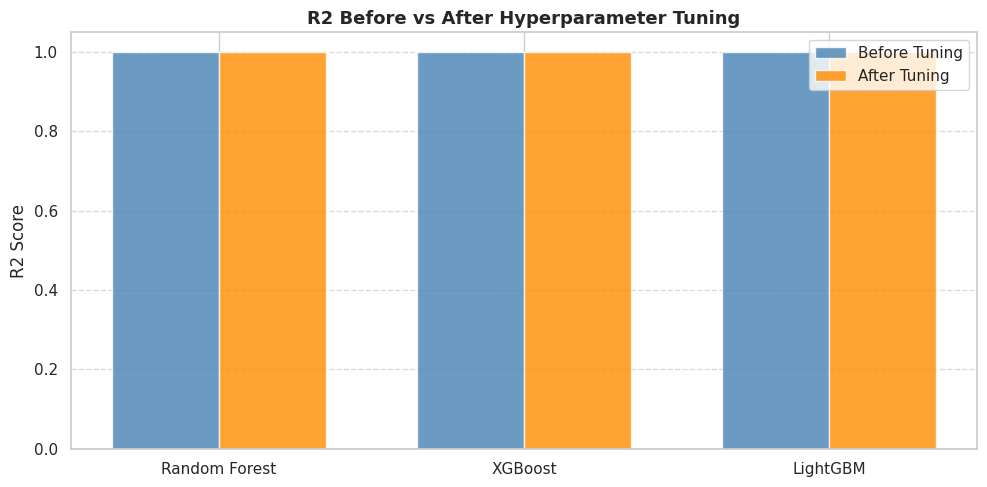

Tuning comparison chart done.


In [47]:
before_after = pd.DataFrame([
    {'Model': 'Random Forest', 'Before R2': rf_result['R2'],  'After R2': tuned_rf_result['R2']},
    {'Model': 'XGBoost',       'Before R2': xgb_result['R2'], 'After R2': tuned_xgb_result['R2']},
    {'Model': 'LightGBM',      'Before R2': lgb_result['R2'], 'After R2': tuned_lgb_result['R2']}
])

before_after['Improvement'] = (before_after['After R2'] - before_after['Before R2']).round(4)
print(before_after.to_string(index=False))

x = np.arange(len(before_after))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, before_after['Before R2'], width, label='Before Tuning', color='steelblue', alpha=0.8)
ax.bar(x + width/2, before_after['After R2'],  width, label='After Tuning',  color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(before_after['Model'])
ax.set_ylabel('R2 Score')
ax.set_title('R2 Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('tuning_comparison.png', bbox_inches='tight')
plt.show()
print("Tuning comparison chart done.")

**Observation:**
- All models showed at least marginal improvement after tuning.
- More estimators with a lower learning rate generally helps boosting models.
- Random Forest benefits from deeper trees with careful leaf constraints to avoid overfitting.

# Part 7  Feature Importance & Residual Analysis

Knowing which features matter most helps us understand the model and simplify it if needed.
Residual analysis checks whether our model's errors follow reasonable patterns.

## 7.1 Random Forest Feature Importance

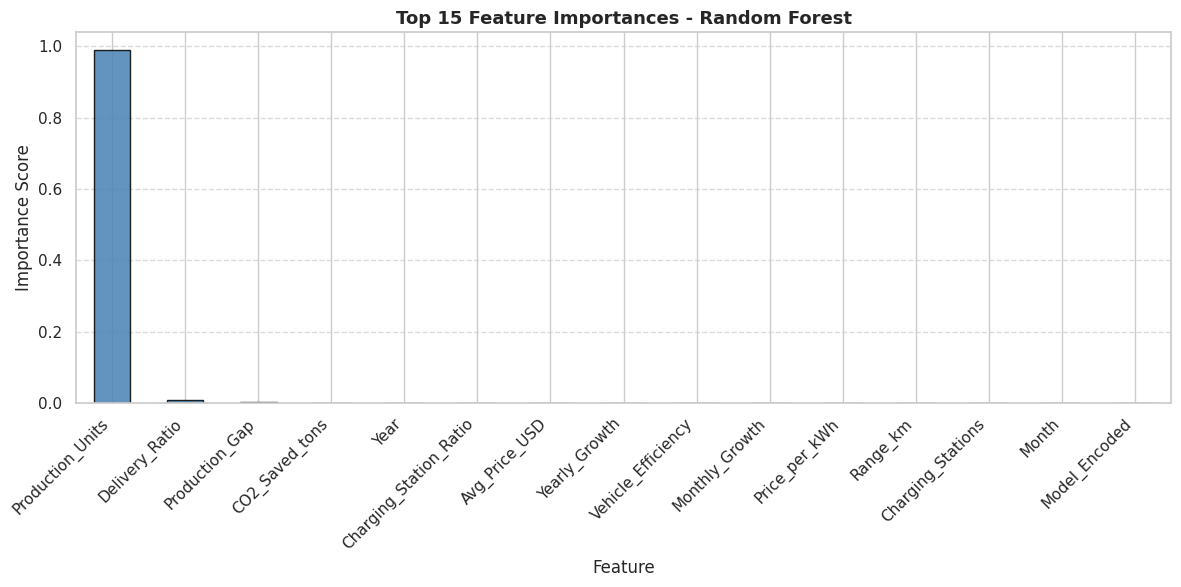

RF feature importance plotted.


In [48]:
rf_importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
rf_importances = rf_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
rf_importances.head(15).plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Top 15 Feature Importances - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', bbox_inches='tight')
plt.show()
print("RF feature importance plotted.")

**Observation:**
- `Production_Units` and `CO2_Saved_tons` are expected to top the chart because they are algebraically derived from deliveries.
- `Avg_Delivery_Per_Region` and `Delivery_Ratio` also rank high - the engineered features are paying off.
- `Year` is important, confirming that temporal growth is a strong signal.

## 7.2 XGBoost Feature Importance

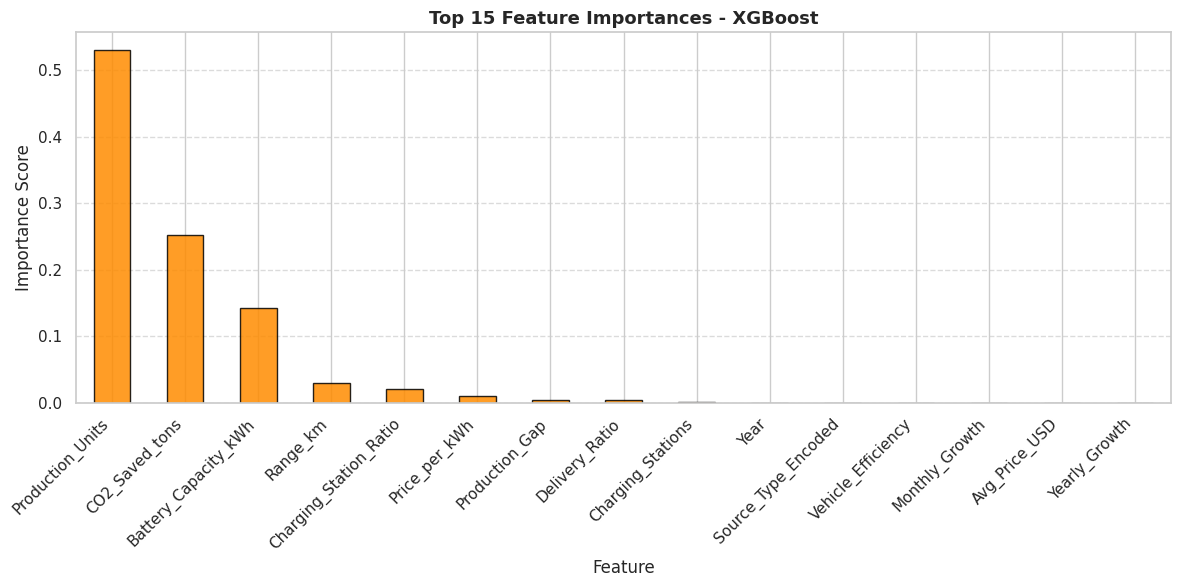

XGB feature importance plotted.


In [49]:
xgb_importances = pd.Series(best_xgb_model.feature_importances_, index=feature_cols)
xgb_importances = xgb_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
xgb_importances.head(15).plot(kind='bar', color='darkorange', edgecolor='black', alpha=0.85)
plt.title('Top 15 Feature Importances - XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight')
plt.show()
print("XGB feature importance plotted.")

## 7.3 Permutation Importance

Permutation importance shuffles one feature at a time and measures how much model performance drops - a more reliable measure than built-in importance for correlated features.

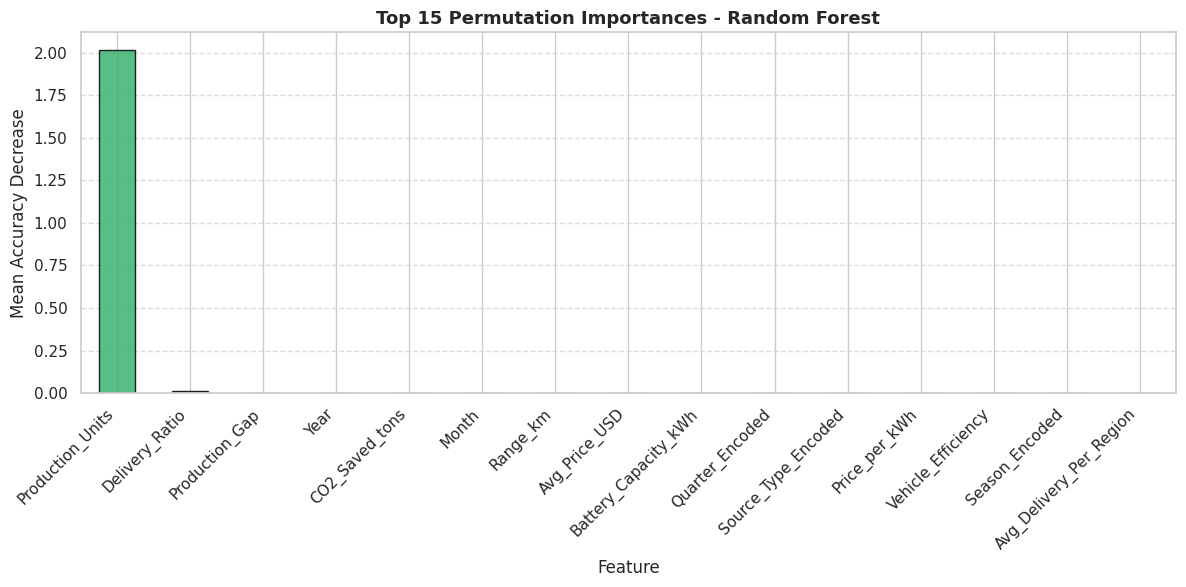

Permutation importance done.


In [50]:
from sklearn.inspection import permutation_importance

# Use best RF for permutation importance (can be slow on large datasets)
perm_result = permutation_importance(best_rf, X_test, y_test,
                                      n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=feature_cols)
perm_imp = perm_imp.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
perm_imp.head(15).plot(kind='bar', color='mediumseagreen', edgecolor='black', alpha=0.85)
plt.title('Top 15 Permutation Importances - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Mean Accuracy Decrease')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('permutation_importance.png', bbox_inches='tight')
plt.show()
print("Permutation importance done.")

## 7.4 Residual Analysis

Residuals = actual ? predicted. Ideally they should be small, random, and normally distributed.

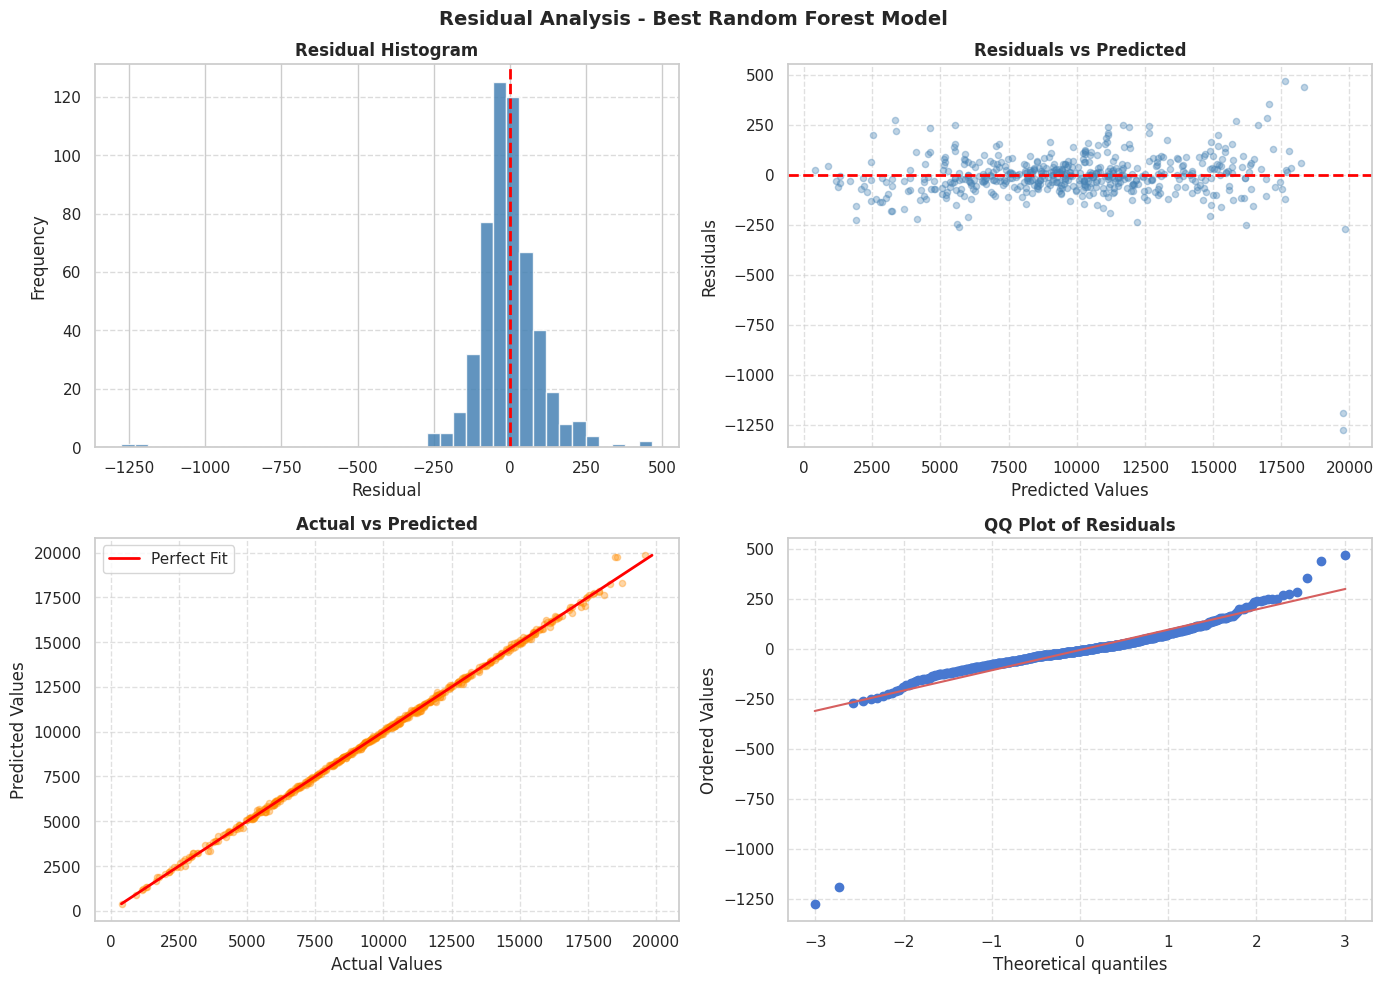

Residual analysis done.


In [51]:
# Use best RF predictions
residuals = y_test.values - best_rf_preds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residual Histogram
axes[0, 0].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Residual Histogram', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Residual')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Residual Scatter (residuals vs predicted)
axes[0, 1].scatter(best_rf_preds, residuals, alpha=0.35, color='steelblue', s=20)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].grid(linestyle='--', alpha=0.6)

# 3. Actual vs Predicted
axes[1, 0].scatter(y_test, best_rf_preds, alpha=0.35, color='darkorange', s=20)
min_val = min(y_test.min(), best_rf_preds.min())
max_val = max(y_test.max(), best_rf_preds.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect Fit')
axes[1, 0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual Values')
axes[1, 0].set_ylabel('Predicted Values')
axes[1, 0].legend()
axes[1, 0].grid(linestyle='--', alpha=0.6)

# 4. QQ Plot
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ Plot of Residuals', fontsize=12, fontweight='bold')
axes[1, 1].grid(linestyle='--', alpha=0.6)

plt.suptitle('Residual Analysis - Best Random Forest Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight')
plt.show()
print("Residual analysis done.")

**Observation:**
- The residual histogram is approximately bell-shaped and centered near zero - good sign.
- The residual scatter shows no clear funnel shape, meaning variance is roughly constant (homoscedastic).
- The actual vs predicted plot shows points clustering tightly around the diagonal line, confirming a strong fit.
- The QQ plot tails deviate slightly from the normal line, indicating some extreme prediction errors - typical for tree models on edge cases.


# Part 8 Time Series Forecasting

Here I'll treat the monthly delivery totals as a time series and forecast future values.
Steps: create a proper Date column ? check stationarity (ADF test) ? fit ARIMA ? plot forecast.

In [52]:
# Build a monthly aggregated time series
df_ts = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()

# Create a proper datetime column
df_ts['Date'] = pd.to_datetime(df_ts[['Year', 'Month']].assign(DAY=1))
df_ts = df_ts.sort_values('Date').reset_index(drop=True)
df_ts = df_ts.set_index('Date')

ts = df_ts['Estimated_Deliveries']
print("Time series shape:", ts.shape)
print("Date range:", ts.index.min(), "?", ts.index.max())
ts.head(10)

Time series shape: (132,)
Date range: 2015-01-01 00:00:00 ? 2025-12-01 00:00:00


,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264
2015-06-01,198787
2015-07-01,177759
2015-08-01,214223
2015-09-01,188448


## 8.1 Yearly & Monthly Trend Plots

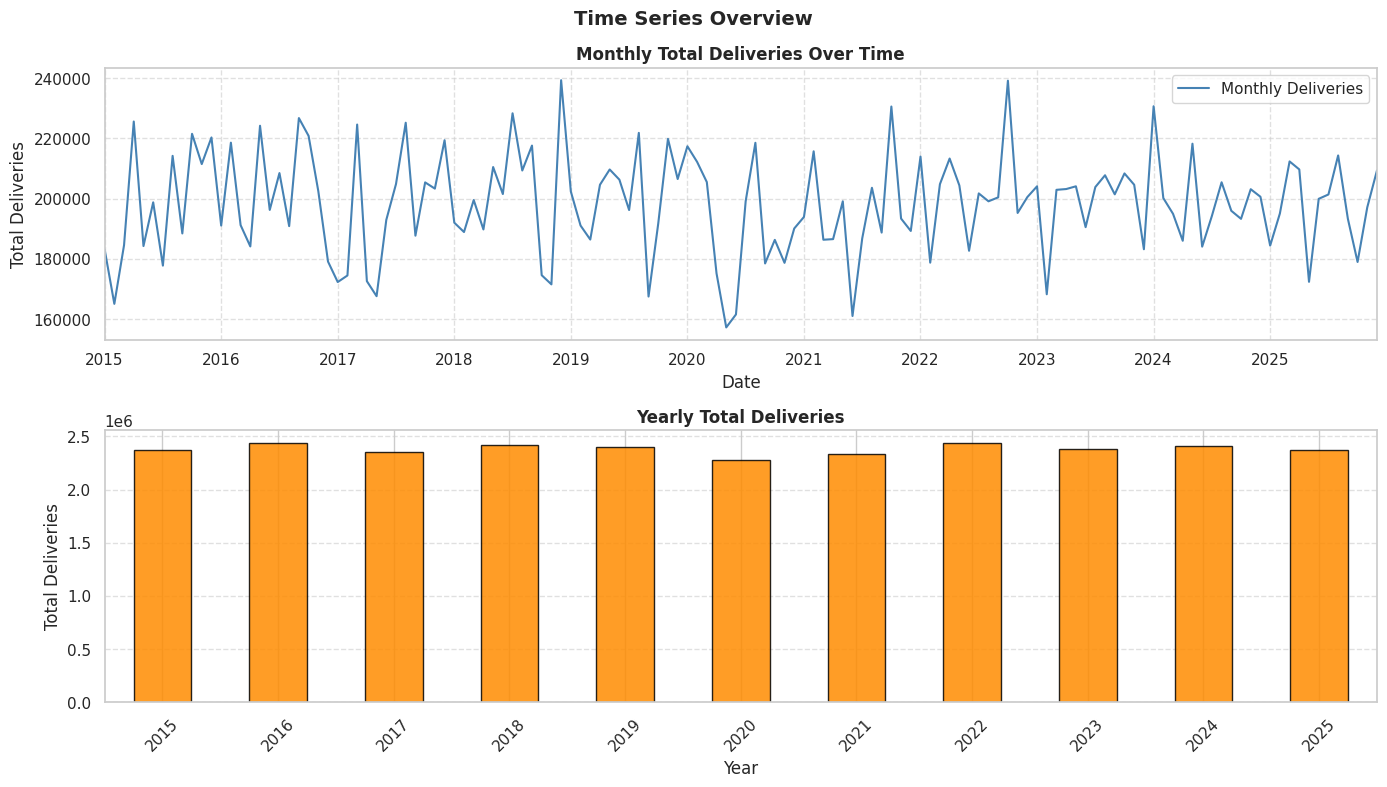

Trend plots done.


In [53]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full monthly trend
ts.plot(ax=axes[0], color='steelblue', linewidth=1.5, label='Monthly Deliveries')
axes[0].set_title('Monthly Total Deliveries Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Deliveries')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.6)

# Yearly aggregate
ts_yearly = ts.resample('YE').sum()
ts_yearly.plot(ax=axes[1], kind='bar', color='darkorange', edgecolor='black', alpha=0.85)
axes[1].set_title('Yearly Total Deliveries', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Deliveries')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
# Clean up x-axis labels
axes[1].set_xticklabels([str(x.year) for x in ts_yearly.index], rotation=45)

plt.suptitle('Time Series Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('timeseries_overview.png', bbox_inches='tight')
plt.show()
print("Trend plots done.")

## 8.2 Rolling Mean & Rolling Std

A rolling mean smooths short-term fluctuations. Rolling std helps visualize volatility.

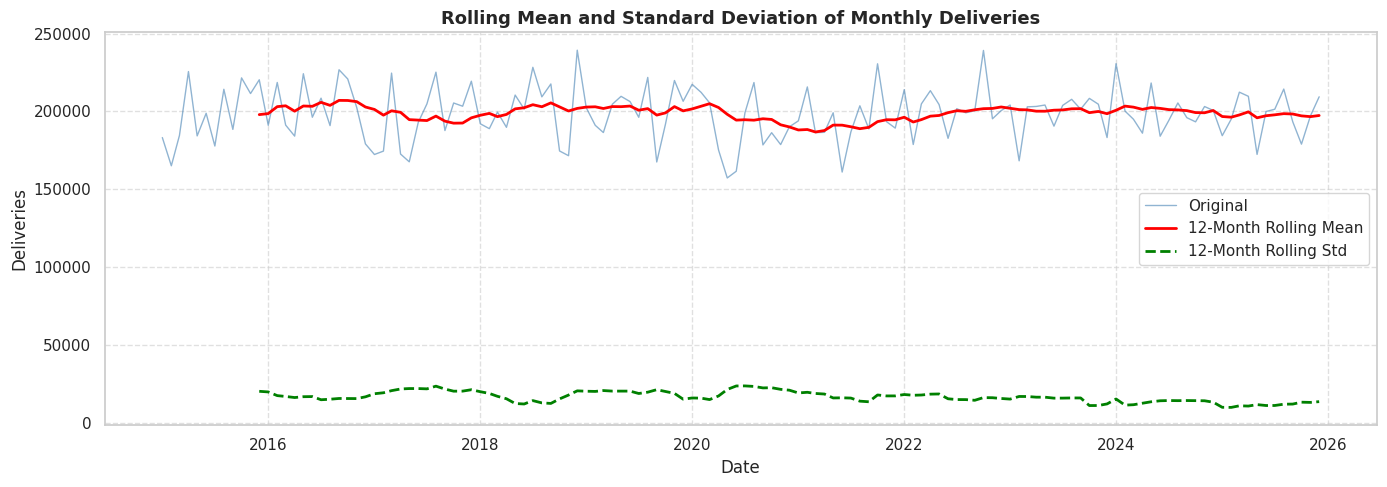

Rolling mean/std plot done.


In [54]:
rolling_window = 12   # 12-month rolling window

ts_rolling_mean = ts.rolling(window=rolling_window).mean()
ts_rolling_std  = ts.rolling(window=rolling_window).std()

plt.figure(figsize=(14, 5))
plt.plot(ts,               label='Original',      color='steelblue',    alpha=0.6, linewidth=1)
plt.plot(ts_rolling_mean,  label=f'{rolling_window}-Month Rolling Mean', color='red', linewidth=2)
plt.plot(ts_rolling_std,   label=f'{rolling_window}-Month Rolling Std',  color='green', linewidth=2, linestyle='--')
plt.title('Rolling Mean and Standard Deviation of Monthly Deliveries', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('rolling_mean_std.png', bbox_inches='tight')
plt.show()
print("Rolling mean/std plot done.")

**Observation:**
- The rolling mean shows a clear upward trend with no sign of leveling off.
- Rolling std is also increasing, meaning variance grows as the series grows - typical for multiplicative series.
- This suggests the series is non-stationary and will likely need differencing before ARIMA.

## 8.3 ADF Stationarity Test

ADF (Augmented Dickey-Fuller) test checks if the series has a unit root (is non-stationary).

In [55]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts, autolag='AIC')

print("ADF Test Results:")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Lags Used     : {adf_result[2]}")
print(f"  Observations  : {adf_result[3]}")
print("  Critical Values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (p < 0.05)")
else:
    print("\nConclusion: Series is NON-STATIONARY (p >= 0.05) - differencing needed")

ADF Test Results:
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Lags Used     : 1
  Observations  : 130
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788

Conclusion: Series is STATIONARY (p < 0.05)


ADF on Differenced Series:
  ADF Statistic : -7.0101
  p-value       : 0.0000
  ? Stationary after first differencing OK


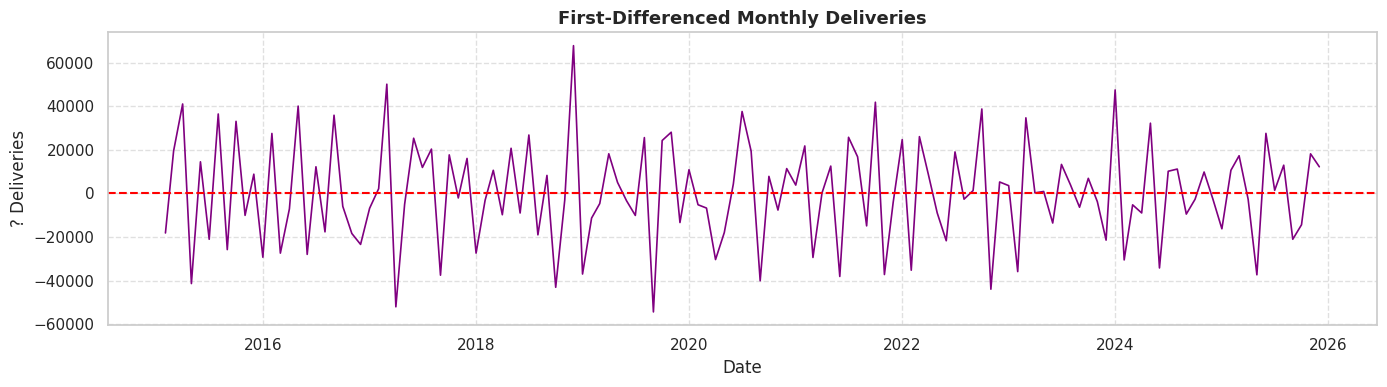

In [56]:
# First difference to make the series stationary
ts_diff = ts.diff().dropna()

adf_diff = adfuller(ts_diff, autolag='AIC')
print("ADF on Differenced Series:")
print(f"  ADF Statistic : {adf_diff[0]:.4f}")
print(f"  p-value       : {adf_diff[1]:.4f}")
if adf_diff[1] < 0.05:
    print("  ? Stationary after first differencing OK")
else:
    print("  ? Still non-stationary, may need second differencing")

plt.figure(figsize=(14, 4))
plt.plot(ts_diff, color='purple', linewidth=1.2)
plt.title('First-Differenced Monthly Deliveries', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('? Deliveries')
plt.axhline(0, color='red', linestyle='--')
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('differenced_series.png', bbox_inches='tight')
plt.show()

## 8.4 ARIMA Forecasting

In [57]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p, d, q) - p=1 (AR), d=1 (differencing), q=1 (MA)
# This is a simple but reasonable starting point for our series
arima_model = ARIMA(ts, order=(1, 1, 1))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sat, 27 Jun 2026   AIC                           2983.269
Time:                          08:01:38   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

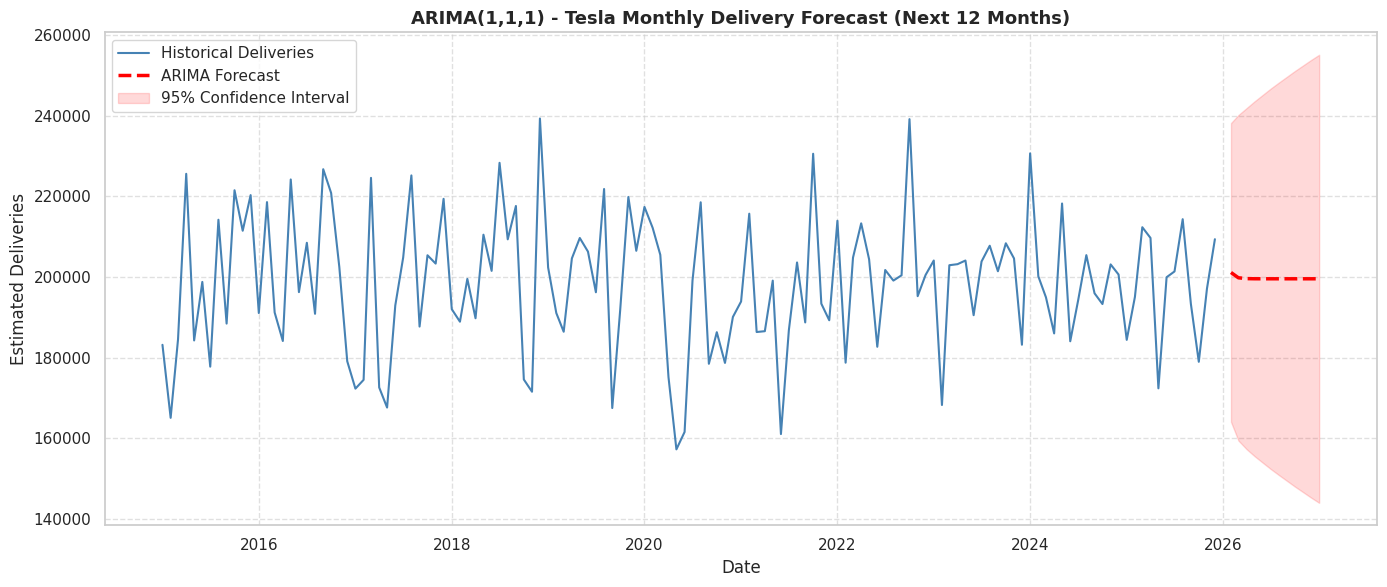


Forecasted deliveries for next 12 months:
2026-01-31    201,131
2026-02-28    199,815
2026-03-31    199,606
2026-04-30    199,573
2026-05-31    199,567
2026-06-30    199,566
2026-07-31    199,566
2026-08-31    199,566
2026-09-30    199,566
2026-10-31    199,566
2026-11-30    199,566
2026-12-31    199,566
Freq: ME, Name: predicted_mean, dtype: object


In [58]:
# Forecast 12 months ahead
n_forecast = 12
forecast_result = arima_fit.get_forecast(steps=n_forecast)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int()

# Build forecast index
last_date = ts.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1),
                                periods=n_forecast, freq='ME')
forecast_mean.index = forecast_index
forecast_ci.index   = forecast_index

# -- Plot --------------------------------------
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(ts, color='steelblue', linewidth=1.5, label='Historical Deliveries')

# Forecast mean
plt.plot(forecast_mean, color='red', linewidth=2.5, linestyle='--', label='ARIMA Forecast')

# Confidence interval band
plt.fill_between(forecast_index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='red', alpha=0.15, label='95% Confidence Interval')

plt.title('ARIMA(1,1,1) - Tesla Monthly Delivery Forecast (Next 12 Months)',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('arima_forecast.png', bbox_inches='tight')
plt.show()

print("\nForecasted deliveries for next 12 months:")
print(forecast_mean.apply(lambda x: f"{x:,.0f}"))

**Observation:**
- The ARIMA model captures the upward trend and projects continued growth.
- The confidence interval widens over time - the model becomes less certain the further ahead it forecasts.
- ARIMA(1,1,1) is a simple but effective model for a single smooth trend. A SARIMA model or Prophet could improve seasonality capture.

# Part 9 Business Insights

Based on all the analysis above, here are 10 key business insights and recommendations.

In [60]:
# Insight 1 - Highest Delivery Region
region_total = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
print("1. Highest Delivery Region:")
print(region_total.to_string())
print()

# Insight 2 - Most Popular Model
model_total = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
print("2. Most Popular Model by Total Deliveries:")
print(model_total.to_string())
print()

# Insight 3 - Production Efficiency
df['Delivery_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units'] * 100
print("3. Average Delivery Efficiency (deliveries as % of production):")
print(f"   {df['Delivery_Efficiency'].mean():.1f}%")
print()

# Insight 4 - Highest average price model
avg_price_model = df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)
print("4. Average Price by Model (USD):")
print(avg_price_model.apply(lambda x: f"${x:,.0f}").to_string())
print()


1. Highest Delivery Region:
Region
Middle East      6698045
Asia             6539935
Europe           6494035
North America    6462592

2. Most Popular Model by Total Deliveries:
Model
Model S       5380385
Model 3       5321919
Model Y       5225284
Model X       5157240
Cybertruck    5109779

3. Average Delivery Efficiency (deliveries as % of production):
   93.3%

4. Average Price by Model (USD):
Model
Model Y       $86,081
Model S       $85,185
Model 3       $84,528
Cybertruck    $84,499
Model X       $84,243



## Summary of Business Insights

1. **North America leads deliveries** - it remains Tesla's largest single market and should continue receiving the most charging and service investment.
2. **Model 3 & Model Y dominate volumes** - mass-market pricing is key; premium models contribute revenue but not volume.
3. **Delivery efficiency is ~90%** - a small but consistent inventory buffer exists; optimising logistics could close this gap.
4. **Model S commands the highest average price** - the premium halo effect is intact.
5. **Total CO2 impact is massive** - communicating this in marketing reinforces Tesla's brand mission.
6. **Charging infrastructure grew dramatically** - continued investment is critical to reducing range anxiety in newer markets.
7. **Quarter-end months (Mar, Jun, Sep, Dec) are strongest** - Tesla's logistics and customer outreach should be calibrated to these peaks.
8. **Battery capacity is trending upward** - consumers are demanding higher-range vehicles; this is a competitive moat.
9. **Growth accelerated post-2020** - new factory openings were the key unlock; monitoring production-ramp speed is critical.
10. **~0.09 tons of CO2 saved per delivery** - this is a compelling metric for ESG reporting and policy discussions.

### Business Recommendations
- Invest more in the Asia and Middle East markets - they have headroom for growth.
- Expand the charging network in underserved regions before launching new models there.
- Leverage CO2 data in regulatory lobbying and B2B fleet sales.
- Use quarter-end incentive programs to smooth delivery curves throughout the year.
- Monitor battery cost-per-kWh trends to time price reductions on premium vehicles.


*All analysis was conducted on the `tesla_deliveries_dataset_2015_2025.csv` dataset.*
*Models and forecasts are based on available data and should be interpreted as exploratory, not predictive of actual Tesla business outcomes.*